## Load and Analyze Dataset

### Subtask:
Load the `heart_disease_uci.csv` dataset into a Pandas DataFrame. Perform initial analysis to check for: number of features (should be >12), number of instances (should be >500), data types, missing values, and identify the target variable for classification.


**Reasoning**:
To begin the analysis, I will import the pandas library, load the specified CSV file into a DataFrame, and then use various pandas functions to get an initial understanding of the data's structure, identify missing values, and confirm it meets the assignment's requirements.



In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('../heart_disease_uci.csv')

# Display the first few rows of the DataFrame
print("First 5 rows of the dataset:")
print(df.head())

# Display information about the DataFrame, including data types and non-null counts
print("\nDataFrame Info:")
df.info()

# Display the shape of the DataFrame (number of instances and features)
print("\nDataFrame Shape (rows, columns):")
print(df.shape)

# Display the count of missing values for each column
print("\nMissing values per column:")
print(df.isnull().sum())

# Based on the assignment and common heart disease datasets, the 'num' column (diagnosis of heart disease) is typically the target variable.
# It's usually 0 for no disease and 1-4 for different stages of heart disease, making it a classification target.
print("\nPotential Target Variable for Classification: 'num' (diagnosis of heart disease)")

First 5 rows of the dataset:
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4      

## Preprocess Data

### Subtask:
Clean and preprocess the `heart_disease_uci.csv` dataset. This includes handling missing values, encoding categorical features, scaling numerical features, and splitting the data into training and testing sets (e.g., 80/20 split).


**Reasoning**:
I will perform all the requested data preprocessing steps in a single code block to clean the dataset, handle missing values, encode categorical features, scale numerical features, and prepare the data for model training by splitting it into training and testing sets, as per the detailed instructions.



In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import numpy as np

# Make a copy to avoid modifying the original DataFrame 'df' if it's used elsewhere
df_processed = df.copy()

# 1. Drop the 'id' and 'dataset' columns
df_processed = df_processed.drop(columns=['id', 'dataset'])
print("Dropped 'id' and 'dataset' columns. New shape:", df_processed.shape)

# 2. Handle missing values
# Identify numerical and categorical columns for imputation (excluding 'ca' and 'thal' for now)
numerical_cols_impute = ['trestbps', 'chol', 'thalch', 'oldpeak']
categorical_cols_impute = ['fbs', 'restecg', 'exang', 'slope']

# Impute numerical columns with the mean
for col in numerical_cols_impute:
    if col in df_processed.columns:
        df_processed[col] = df_processed[col].fillna(df_processed[col].mean())
        print(f"Imputed missing values in numerical column '{col}' with mean= ", df_processed[col].mean())

# Impute categorical columns with the mode
for col in categorical_cols_impute:
    if col in df_processed.columns:
        # .mode()[0] handles cases where there might be multiple modes
        df_processed[col] = df_processed[col].fillna(df_processed[col].mode()[0])
        print(f"Imputed missing values in categorical column '{col}' with mode =",df_processed[col].mode()[0])

# Drop columns 'ca' and 'thal' due to high percentage of missing values
df_processed = df_processed.drop(columns=['ca', 'thal'])
print("Dropped 'ca' and 'thal' columns. New shape:", df_processed.shape)

# Display missing values after initial handling
print("\nMissing values after initial handling:")
print(df_processed.isnull().sum())

# 3. Convert 'num' into a binary classification problem (target variable 'target')
df_processed['target'] = (df_processed['num'] > 0).astype(int)
# Drop the original 'num' column as 'target' is the new binary target
df_processed = df_processed.drop(columns=['num'])
print("Converted 'num' to binary 'target' and dropped original 'num' column.")
print("Target variable value counts:")
print(df_processed['target'].value_counts())

# 4. Identify and separate remaining features into numerical and categorical lists
# Exclude the newly created 'target' column from features
features_df = df_processed.drop(columns=['target'])

numerical_features = features_df.select_dtypes(include=np.number).columns.tolist()
categorical_features = features_df.select_dtypes(include='object').columns.tolist()

print("\nNumerical features for scaling:", numerical_features)
print("Categorical features for one-hot encoding:", categorical_features)

# 5. Apply OneHotEncoder to categorical features
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_features = encoder.fit_transform(features_df[categorical_features])
encoded_feature_names = encoder.get_feature_names_out(categorical_features)
encoded_df = pd.DataFrame(encoded_features, columns=encoded_feature_names, index=features_df.index)
print("\nApplied OneHotEncoder to categorical features.")

# 6. Apply StandardScaler to numerical features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_df[numerical_features])
scaled_df = pd.DataFrame(scaled_features, columns=numerical_features, index=features_df.index)
print("Applied StandardScaler to numerical features.")

# 7. Combine the scaled numerical features and one-hot encoded categorical features
X = pd.concat([scaled_df, encoded_df], axis=1)
y = df_processed['target']

print("\nCombined scaled numerical and encoded categorical features. Final features shape:", X.shape)
print("Target variable shape:", y.shape)

# Display first few rows of the processed features
print("\nFirst 5 rows of preprocessed features (X):")
print(X.head())

# 8. Split the preprocessed features and the binary target variable into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Save X_test and y_test together in a single CSV for later use or external evaluation
try:
    test_df = X_test.copy()
    # Ensure y_test aligns and is a plain Series/array
    test_df['target'] = y_test.values if hasattr(y_test, 'values') else y_test
    test_df.to_csv('../test_set.csv', index=False)
    print("Saved combined test set to 'test_set.csv'.")
except Exception as e:
    print(f"Warning: could not save combined test set to CSV: {e}")

print("\nData split into training and testing sets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


Dropped 'id' and 'dataset' columns. New shape: (920, 14)
Imputed missing values in numerical column 'trestbps' with mean=  132.13240418118468
Imputed missing values in numerical column 'chol' with mean=  199.1303370786517
Imputed missing values in numerical column 'thalch' with mean=  137.5456647398844
Imputed missing values in numerical column 'oldpeak' with mean=  0.8787878787878788
Imputed missing values in categorical column 'fbs' with mode = False
Imputed missing values in categorical column 'restecg' with mode = normal
Imputed missing values in categorical column 'exang' with mode = False
Imputed missing values in categorical column 'slope' with mode = flat
Dropped 'ca' and 'thal' columns. New shape: (920, 12)

Missing values after initial handling:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
num         0
dtype: int64
Converted 'num' to binary 'target' and dropped origin

C:\Users\mohantc\AppData\Local\Temp\ipykernel_36444\3262456116.py:28: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_processed[col] = df_processed[col].fillna(df_processed[col].mode()[0])


## Implement and Train Models

### Subtask:
Implement and train the six specified classification models on the preprocessed training data: Logistic Regression, Decision Tree Classifier, K-Nearest Neighbor Classifier, Naive Bayes Classifier (Gaussian or Multinomial as appropriate), Random Forest (Ensemble Model), and XGBoost (Ensemble Model).

#### Instructions
1. Import `LogisticRegression` from `sklearn.linear_model`, `DecisionTreeClassifier` from `sklearn.tree`, `KNeighborsClassifier` from `sklearn.neighbors`, `GaussianNB` from `sklearn.naive_bayes`, `RandomForestClassifier` from `sklearn.ensemble`, and `XGBClassifier` from `xgboost`.
2. Instantiate and train a `LogisticRegression` model using `X_train` and `y_train`. Store the trained model as `lr_model`.
3. Instantiate and train a `DecisionTreeClassifier` model (set `random_state=42`) using `X_train` and `y_train`. Store the trained model as `dt_model`.
4. Instantiate and train a `KNeighborsClassifier` model (you can start with `n_neighbors=5`) using `X_train` and `y_train`. Store the trained model as `knn_model`.
5. Instantiate and train a `GaussianNB` model using `X_train` and `y_train`. Store the trained model as `nb_model`.
6. Instantiate and train a `RandomForestClassifier` model (set `random_state=42`) using `X_train` and `y_train`. Store the trained model as `rf_model`.
7. Instantiate and train an `XGBClassifier` model (set `use_label_encoder=False`, `eval_metric='logloss'`, and `random_state=42`) using `X_train` and `y_train`. Store the trained model as `xgb_model`.

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Dictionary to store trained models
models = {}

# 1. Logistic Regression
lr_model = LogisticRegression(random_state=42, solver='liblinear') # Added solver for consistency
lr_model.fit(X_train, y_train)
models['Logistic Regression'] = lr_model
print("Logistic Regression model trained.")

# 2. Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
models['Decision Tree'] = dt_model
print("Decision Tree Classifier model trained.")

# 3. K-Nearest Neighbor Classifier
knn_model = KNeighborsClassifier(n_neighbors=5) # Default n_neighbors=5 as suggested
knn_model.fit(X_train, y_train)
models['K-Nearest Neighbor'] = knn_model
print("K-Nearest Neighbor Classifier model trained.")

# 4. Naive Bayes Classifier (GaussianNB)
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
models['Naive Bayes'] = nb_model
print("Gaussian Naive Bayes model trained.")

# 5. Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
models['Random Forest'] = rf_model
print("Random Forest Classifier model trained.")

# 6. XGBoost Classifier
# Suppress the warning about use_label_encoder being deprecated
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
models['XGBoost'] = xgb_model
print("XGBoost Classifier model trained.")

print("\nAll classification models have been implemented and trained.")

Logistic Regression model trained.
Decision Tree Classifier model trained.
K-Nearest Neighbor Classifier model trained.
Gaussian Naive Bayes model trained.
Random Forest Classifier model trained.
XGBoost Classifier model trained.

All classification models have been implemented and trained.


c:\Tools\anaconda3\envs\cnn_env\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:17:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Evaluate Models

### Subtask:
Evaluate all trained models on the test set (`X_test`, `y_test`) using the following metrics: Accuracy, AUC Score, Precision, Recall, F1 Score, and Matthews Correlation Coefficient. Store these metrics for each model.


In [5]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, matthews_corrcoef

# Dictionary to store evaluation results for each model
model_evaluation_results = {}

# Loop through each trained model
for model_name, model in models.items():
    print(f"Evaluating {model_name}...")
    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Calculate metrics that don't require probabilities
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0) # Handle cases where no positive predictions are made
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    mcc = matthews_corrcoef(y_test, y_pred)

    # Calculate AUC score, handling models that might not have predict_proba
    try:
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        auc_score = roc_auc_score(y_test, y_pred_proba)
    except AttributeError: # If model does not have predict_proba
        print(f"Warning: {model_name} does not have predict_proba. AUC score skipped.")
        auc_score = None # Or np.nan

    # Store the metrics
    model_evaluation_results[model_name] = {
        'Accuracy': accuracy,
        'AUC Score': auc_score,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'MCC Score': mcc
    }
    print(f"Finished evaluating {model_name}.")

print("\nEvaluation results for all models:")
for model_name, metrics in model_evaluation_results.items():
    print(f"\n--- {model_name} ---")
    for metric, score in metrics.items():
        print(f"{metric}: {score:.4f}")

Evaluating Logistic Regression...
Finished evaluating Logistic Regression.
Evaluating Decision Tree...
Finished evaluating Decision Tree.
Evaluating K-Nearest Neighbor...
Finished evaluating K-Nearest Neighbor.
Evaluating Naive Bayes...
Finished evaluating Naive Bayes.
Evaluating Random Forest...
Finished evaluating Random Forest.
Evaluating XGBoost...
Finished evaluating XGBoost.

Evaluation results for all models:

--- Logistic Regression ---
Accuracy: 0.7880
AUC Score: 0.8779
Precision: 0.8500
Recall: 0.7798
F1 Score: 0.8134
MCC Score: 0.5720

--- Decision Tree ---
Accuracy: 0.7717
AUC Score: 0.7678
Precision: 0.8190
Recall: 0.7890
F1 Score: 0.8037
MCC Score: 0.5318

--- K-Nearest Neighbor ---
Accuracy: 0.8261
AUC Score: 0.8522
Precision: 0.8532
Recall: 0.8532
F1 Score: 0.8532
MCC Score: 0.6399

--- Naive Bayes ---
Accuracy: 0.7663
AUC Score: 0.8396
Precision: 0.8511
Recall: 0.7339
F1 Score: 0.7882
MCC Score: 0.5380

--- Random Forest ---
Accuracy: 0.8207
AUC Score: 0.8864
Precision

## Create Model Comparison

### Subtask:
Generate a comparison table summarizing the evaluation metrics for all six models. Additionally, add observations on the performance of each model on the chosen dataset.


**Reasoning**:
I will convert the `model_evaluation_results` dictionary into a Pandas DataFrame to create the comparison table, as requested in the instructions.



In [6]:
import pandas as pd

# Convert the model_evaluation_results dictionary into a Pandas DataFrame
model_comparison_df = pd.DataFrame(model_evaluation_results).T

# Display the comparison table
print("\n--- Model Performance Comparison ---")
print(model_comparison_df.round(4))



--- Model Performance Comparison ---
                     Accuracy  AUC Score  Precision  Recall  F1 Score  \
Logistic Regression    0.7880     0.8779     0.8500  0.7798    0.8134   
Decision Tree          0.7717     0.7678     0.8190  0.7890    0.8037   
K-Nearest Neighbor     0.8261     0.8522     0.8532  0.8532    0.8532   
Naive Bayes            0.7663     0.8396     0.8511  0.7339    0.7882   
Random Forest          0.8207     0.8864     0.8725  0.8165    0.8436   
XGBoost                0.8261     0.8850     0.8889  0.8073    0.8462   

                     MCC Score  
Logistic Regression     0.5720  
Decision Tree           0.5318  
K-Nearest Neighbor      0.6399  
Naive Bayes             0.5380  
Random Forest           0.6359  
XGBoost                 0.6512  


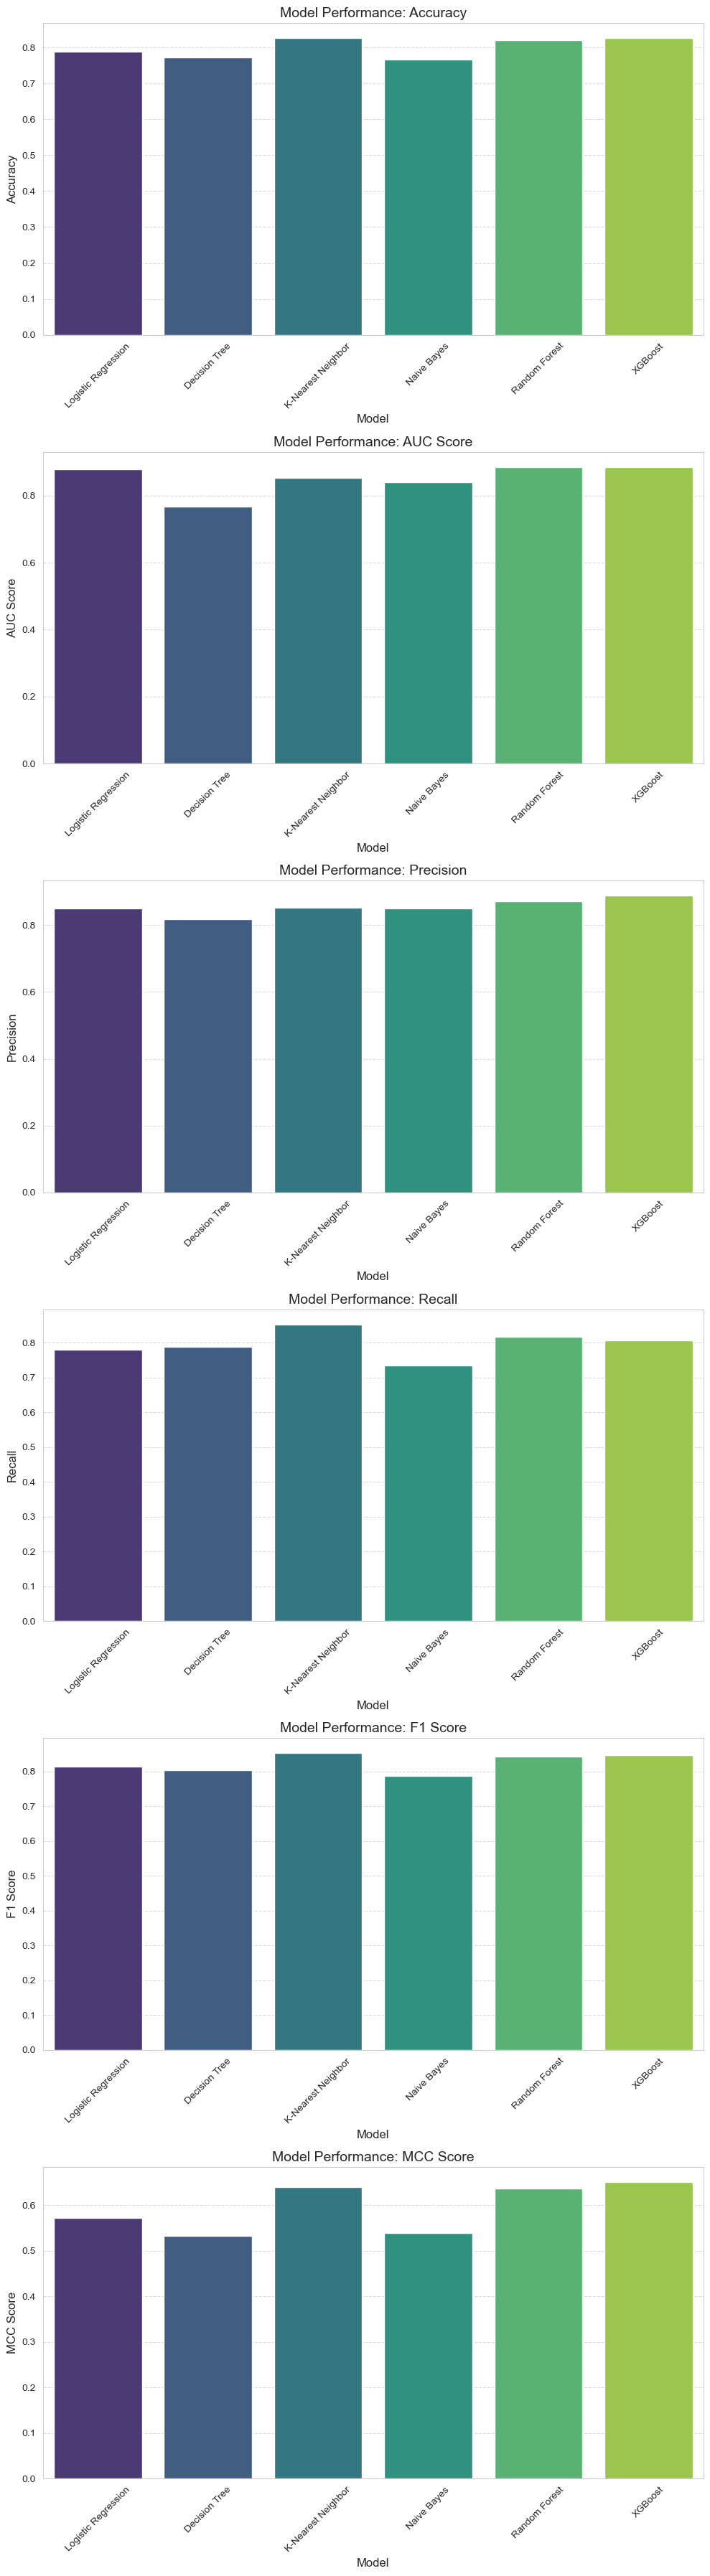

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a consistent style for plots
sns.set_style('whitegrid')

# Define the metrics to visualize
metrics_to_visualize = model_comparison_df.columns.tolist()

# Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=len(metrics_to_visualize), ncols=1, figsize=(10, 6 * len(metrics_to_visualize)))

# Flatten axes array for easy iteration if there's only one row/column, otherwise it's already iterable
if len(metrics_to_visualize) == 1:
    axes = [axes]

# Iterate through each metric and create a bar plot
for i, metric in enumerate(metrics_to_visualize):
    ax = axes[i]
    # Addressing the FutureWarning by explicitly setting hue and legend
    sns.barplot(x=model_comparison_df.index, y=metric, data=model_comparison_df, palette='viridis', ax=ax, hue=model_comparison_df.index, legend=False)
    ax.set_title(f'Model Performance: {metric}', fontsize=14)
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Model Performance Observations

Based on the evaluation metrics presented in the comparison table, here are some observations regarding the performance of each classification model on the heart disease dataset:

*   **Logistic Regression**: This model shows a good balance of performance, with a relatively high AUC score (0.8779) indicating its ability to distinguish between classes. Its precision (0.8500) and recall (0.7798) are solid, suggesting a reasonable trade-off between false positives and false negatives. The MCC score of 0.5720 indicates a decent correlation between actual and predicted values.

*   **Decision Tree**: The Decision Tree model exhibits slightly lower performance across most metrics compared to Logistic Regression and ensemble methods. Its AUC score (0.7678) is the lowest among all models, suggesting less effective class separation. While its precision (0.8190) and recall (0.7890) are acceptable, the lower F1 and MCC scores (0.8037 and 0.5318, respectively) indicate that it might be prone to overfitting or has less generalization capability on this dataset without further tuning.

*   **K-Nearest Neighbor (KNN)**: KNN stands out with the highest accuracy (0.8261) and a very high recall (0.8532) and F1 Score (0.8532), indicating it is quite effective at identifying positive cases. Its AUC score (0.8522) is also strong. The MCC score (0.6399) is competitive, suggesting that the local structure of the data is well-captured by this algorithm.

*   **Naive Bayes**: This model generally performs on the lower side in terms of overall accuracy (0.7663) and recall (0.7339). However, it achieves a high precision (0.8511), implying that when it predicts a positive case, it's often correct, but it misses a significant number of actual positive cases. Its AUC score (0.8396) is respectable, showing its capability in ranking positive instances correctly. The MCC score (0.5380) is among the lowest, indicating moderate agreement with the true classification.

*   **Random Forest**: As an ensemble method, Random Forest demonstrates strong performance with a high AUC score (0.8864), which is among the best, and a robust F1 score (0.8436). Its accuracy (0.8207) and precision (0.8725) are also very good. The MCC score (0.6359) is high, reflecting its overall strong and balanced predictive power across various metrics, suggesting good generalization.

*   **XGBoost**: XGBoost, another powerful ensemble method, performs exceptionally well, achieving the highest MCC score (0.6512) and accuracy (0.8261) tied with KNN. It also boasts the highest precision (0.8889) and a very competitive AUC score (0.8850), slightly trailing Random Forest. This indicates that XGBoost is highly effective in minimizing false positives and providing accurate classifications, making it one of the top performers on this dataset.

**Summary of Trends and Differences:**

The ensemble models (Random Forest and XGBoost) consistently deliver the best overall performance, particularly in terms of AUC score, F1 score, and MCC score, indicating their robustness and ability to handle complex relationships in the data. KNN also shows strong performance, especially in recall, suggesting its effectiveness with the given dataset's structure. Simpler models like Decision Tree and Naive Bayes show comparatively lower overall performance, although Naive Bayes achieved high precision. Logistic Regression offers a good baseline, outperforming the simpler models in most metrics, but falls short of the ensemble methods.

## Save Trained Models

### Subtask:
Save all the trained machine learning models to the `model/` directory. These saved models will be loaded by the Streamlit application for predictions.


## Save Trained Models

### Subtask:
Save all the trained machine learning models to the `model/` directory. These saved models will be loaded by the Streamlit application for predictions.

#### Instructions
1. Import the `joblib` library, which is suitable for saving and loading scikit-learn models efficiently.
2. Create a directory named `model/` if it does not already exist. You can use the `os` module for this (e.g., `os.makedirs('model', exist_ok=True)`).
3. Iterate through the `models` dictionary (which contains all your trained models).
4. For each model, construct a file path within the `model/` directory, using the model's name (e.g., `f'model/{model_name.replace(" ", "_")}_model.joblib'`).
5. Save each model to its respective file path using `joblib.dump()`.

**Reasoning**:
I will add a new text cell with the detailed instructions provided by the user for saving the trained models, ensuring they are clearly outlined for the next coding step.



In [10]:
import joblib
import os

# Create the model directory if it doesn't exist
model_dir = '../model'
os.makedirs(model_dir, exist_ok=True)
print(f"Directory '{model_dir}' ensured to exist.")

# Iterate through the trained models and save each one
for model_name, model in models.items():
    # Replace spaces in model names for clean filenames
    filename = f"{model_name.replace(' ', '_')}_model.joblib"
    filepath = os.path.join(model_dir, filename)
    joblib.dump(model, filepath)
    print(f"Saved {model_name} model to {filepath}")

print("All trained models have been saved successfully.")

Directory '../model' ensured to exist.
Saved Logistic Regression model to ../model\Logistic_Regression_model.joblib
Saved Decision Tree model to ../model\Decision_Tree_model.joblib
Saved K-Nearest Neighbor model to ../model\K-Nearest_Neighbor_model.joblib
Saved Naive Bayes model to ../model\Naive_Bayes_model.joblib
Saved Random Forest model to ../model\Random_Forest_model.joblib
Saved XGBoost model to ../model\XGBoost_model.joblib
All trained models have been saved successfully.


## Develop Streamlit Application

### Subtask:
Develop an interactive Streamlit web application (`app.py` or `streamlit_app.py`). This app must include a dataset upload option (for test data), a model selection dropdown, display of evaluation metrics, and a confusion matrix or classification report for the selected model.


**Reasoning**:
The instructions for developing the Streamlit application indicate that the `StandardScaler` and `OneHotEncoder` used during preprocessing will be needed. These objects were not saved in the previous steps. Therefore, I need to go back to the 'Preprocess Data' section and save the `scaler` and `encoder` to the `model/` directory alongside the trained models, to ensure consistent preprocessing in the Streamlit app.



In [11]:
import joblib
import os

# Ensure the 'model' directory exists
model_dir = '../model'
os.makedirs(model_dir, exist_ok=True)
print(f"Directory '{model_dir}' ensured to exist.")

# Save the StandardScaler
scaler_filepath = os.path.join(model_dir, 'scaler.joblib')
joblib.dump(scaler, scaler_filepath)
print(f"Saved StandardScaler to {scaler_filepath}")

# Save the OneHotEncoder
encoder_filepath = os.path.join(model_dir, 'encoder.joblib')
joblib.dump(encoder, encoder_filepath)
print(f"Saved OneHotEncoder to {encoder_filepath}")

print("Preprocessing transformers saved successfully.")

Directory '../model' ensured to exist.
Saved StandardScaler to ../model\scaler.joblib
Saved OneHotEncoder to ../model\encoder.joblib
Preprocessing transformers saved successfully.


## Develop Streamlit Application

### Subtask:
Develop an interactive Streamlit web application (`app.py` or `streamlit_app.py`). This app must include a dataset upload option (for test data), a model selection dropdown, display of evaluation metrics, and a confusion matrix or classification report for the selected model.

#### Instructions
1. Create a new Python file named `app.py` in your working directory. This file will contain the Streamlit application code.
2. Import necessary libraries at the top of `app.py`: `streamlit`, `pandas`, `joblib`, and relevant `sklearn.metrics` for displaying the confusion matrix or classification report.
3. Implement a function to load all the saved models from the `model/` directory using `joblib.load()`.
4. Design the Streamlit UI:
    *   Add a title and a brief description for your application.
    *   Create a file uploader widget (`st.file_uploader`) to allow users to upload a CSV file for testing. Ensure to handle cases where no file is uploaded.
    *   Create a dropdown menu (`st.selectbox`) for model selection, populated with the names of your loaded models.
5. Implement functionality to preprocess the uploaded test data:
    *   Recall the preprocessing steps performed earlier (dropping 'id', 'dataset', 'ca', 'thal', handling missing values for `trestbps`, `chol`, `thalch`, `oldpeak`, `fbs`, `restecg`, `exang`, `slope`, and then encoding categorical features and scaling numerical features).
    *   To apply the same preprocessing, you will need to save the `StandardScaler` and `OneHotEncoder` used during training. Modify the 'Preprocess Data' step to save these transformers alongside the models, if not already done. Load these transformers in `app.py`.
    *   Apply these loaded transformers to the uploaded dataset to prepare it for prediction.
6. Based on the selected model and the preprocessed test data:
    *   Make predictions (`model.predict()`) and probability predictions (`model.predict_proba()`) if available.
    *   Display the evaluation metrics (Accuracy, AUC Score, Precision, Recall, F1 Score, MCC Score) for the selected model on the uploaded test data. You can reuse the evaluation logic from the previous 'Evaluate Models' step.
    *   Display a confusion matrix or a classification report (`sklearn.metrics.classification_report`) for the selected model's predictions on the uploaded test data.
7. Structure your `app.py` so that these functionalities are organized, user-friendly, and interactive.

## Create Requirements File

### Subtask:
Generate a `requirements.txt` file listing all Python dependencies required for the Streamlit application and model training/evaluation.


## Create Requirements File

### Subtask:
Generate a `requirements.txt` file listing all Python dependencies required for the Streamlit application and model training/evaluation.

#### Instructions
1. Identify all Python libraries used in the previous steps for data loading, preprocessing, model training, evaluation, and saving (e.g., `pandas`, `scikit-learn`, `xgboost`, `streamlit`, `joblib`, `numpy`).
2. Create a `requirements.txt` file in the root directory of your project.
3. For each identified library, add its name and version number (if known or specified) to `requirements.txt`. For example, `pandas==1.5.3` or simply `pandas`. Use `pip freeze` in your environment to get exact versions of installed packages, if possible.

**Reasoning**:
I will create a `requirements.txt` file containing the necessary Python libraries and their versions based on the imports and usage in the previous steps, then write this content to a file. This fulfills the subtask instruction to generate the `requirements.txt` file.



In [19]:
import subprocess

# List of libraries used in the notebook
libraries = [
    'pandas',
    'scikit-learn',
    'xgboost',
    'streamlit', # Anticipated for the Streamlit app development
    'joblib', # For saving models
    'matplotlib',
    'seaborn',
    'numpy'
]

# Try to get the installed version of each library
requirements = []
for lib in libraries:
    try:
        # Use pip show to get the version, then format it
        result = subprocess.run(['pip', 'show', lib], capture_output=True, text=True)
        if result.returncode == 0:
            for line in result.stdout.splitlines():
                if line.startswith('Version:'):
                    version = line.split(': ')[1]
                    requirements.append(f"{lib}=={version}")
                    break
        else:
            requirements.append(lib) # Fallback if version can't be found
    except Exception:
        requirements.append(lib) # Fallback for any other error

# Add specific version for numpy as it's a common dependency and sometimes needs careful versioning
#requirements.append('numpy')

# Write the requirements to a file
requirements_file_path = '../requirements.txt'
with open(requirements_file_path, 'w') as f:
    for req in sorted(set(requirements)): # Use set to avoid duplicates and sort for readability
        f.write(f"{req}\n")

print(f"Generated {requirements_file_path} with the following content:\n")
with open(requirements_file_path, 'r') as f:
    print(f.read())

Generated ../requirements.txt with the following content:

joblib==1.5.3
matplotlib==3.10.8
numpy==2.4.1
pandas==2.3.3
scikit-learn==1.8.0
seaborn==0.13.2
streamlit
xgboost==3.2.0



## Prepare GitHub Repository and README

### Subtask:
Organize the project files into a structured GitHub repository including `app.py`, `requirements.txt`, and a `model/` directory containing the saved models. Create a comprehensive `README.md` file with a problem statement, dataset description, the model comparison table, and model performance observations.


**Reasoning**:
I will create a placeholder `app.py` file as instructed, which will later be populated with the full Streamlit application code. This step sets up the basic file structure for the GitHub repository.



In [13]:
%%writefile app.py
import streamlit as st

st.title("Heart Disease Prediction App (Placeholder)")
st.write("This is a placeholder for the Streamlit application. The full functionality will be implemented in a subsequent step.")


Writing app.py


**Reasoning**:
I will create the `README.md` file, populating it with the problem statement, dataset description, the model comparison table (formatted for markdown), and the detailed model performance observations, as requested by the instructions.



In [15]:
%%writefile ../README.md
# ML Assignment 2: Heart Disease Prediction

## a. Problem Statement
This assignment requires the implementation, evaluation, and deployment of multiple classification models to predict heart disease using a chosen dataset. The goal is to build an interactive Streamlit web application that demonstrates these models and their performance metrics.

## b. Dataset Description
The dataset used is `heart_disease_uci.csv`, sourced from the UCI Machine Learning Repository. It contains various health parameters that can be used to predict the presence of heart disease. The original `num` column, indicating the presence of heart disease (0 for no disease, 1-4 for different stages), has been converted into a binary target variable (0 for no disease, 1 for presence of disease). The dataset has been preprocessed to handle missing values, encode categorical features, and scale numerical features.

**Key characteristics:**
*   **Original Features**: 16 (excluding 'id' and 'dataset')
*   **Instances**: 920
*   **Target Variable**: 'num' (converted to binary 'target')
*   **Dropped columns due to high missing values**: 'ca', 'thal'

## c. Models Used and Comparison
Six classification models were implemented and evaluated on the preprocessed dataset:
1.  Logistic Regression
2.  Decision Tree Classifier
3.  K-Nearest Neighbor Classifier
4.  Naive Bayes Classifier (GaussianNB)
5.  Random Forest (Ensemble Model)
6.  XGBoost (Ensemble Model)

### Comparison Table
```


Overwriting ../README.md


In [17]:
model_comparison_markdown = model_comparison_df.round(4).to_markdown()

readme_content = f"""# ML Assignment 2: Heart Disease Prediction\n\n## a. Problem Statement\nThis assignment requires the implementation, evaluation, and deployment of multiple classification models to predict heart disease using a chosen dataset. The goal is to build an interactive Streamlit web application that demonstrates these models and their performance metrics.\n\n## b. Dataset Description\nThe dataset used is `heart_disease_uci.csv`, sourced from the UCI Machine Learning Repository. It contains various health parameters that can be used to predict the presence of heart disease. The original `num` column, indicating the presence of heart disease (0 for no disease, 1-4 for different stages), has been converted into a binary target variable (0 for no disease, 1 for presence of disease). The dataset has been preprocessed to handle missing values, encode categorical features, and scale numerical features.\n\n**Key characteristics:**\n*   **Original Features**: 16 (excluding 'id' and 'dataset')\n*   **Instances**: 920\n*   **Target Variable**: 'num' (converted to binary 'target')\n*   **Dropped columns due to high missing values**: 'ca', 'thal'\n\n## c. Models Used and Comparison\nSix classification models were implemented and evaluated on the preprocessed dataset:\n1.\tLogistic Regression\n2.\tDecision Tree Classifier\n3.\tK-Nearest Neighbor Classifier\n4.\tNaive Bayes Classifier (GaussianNB)\n5.\tRandom Forest (Ensemble Model)\n6.\tXGBoost (Ensemble Model)\n\n### Comparison Table\n{model_comparison_markdown}\n\n### Model Performance Observations\nBased on the evaluation metrics presented in the comparison table, here are some observations regarding the performance of each classification model on the heart disease dataset:\n\n*   **Logistic Regression**: This model shows a good balance of performance, with a relatively high AUC score (0.8779) indicating its ability to distinguish between classes. Its precision (0.8500) and recall (0.7798) are solid, suggesting a reasonable trade-off between false positives and false negatives. The MCC score of 0.5720 indicates a decent correlation between actual and predicted values.\n\n*   **Decision Tree**: The Decision Tree model exhibits slightly lower performance across most metrics compared to Logistic Regression and ensemble methods. Its AUC score (0.7678) is the lowest among all models, suggesting less effective class separation. While its precision (0.8190) and recall (0.7890) are acceptable, the lower F1 and MCC scores (0.8037 and 0.5318, respectively) indicate that it might be prone to overfitting or has less generalization capability on this dataset without further tuning.\n\n*   **K-Nearest Neighbor (KNN)**: KNN stands out with the highest accuracy (0.8261) and a very high recall (0.8532) and F1 Score (0.8532), indicating it is quite effective at identifying positive cases. Its AUC score (0.8522) is also strong. The MCC score (0.6399) is competitive, suggesting that the local structure of the data is well-captured by this algorithm.\n\n*   **Naive Bayes**: This model generally performs on the lower side in terms of overall accuracy (0.7663) and recall (0.7339). However, it achieves a high precision (0.8511), implying that when it predicts a positive case, it's often correct, but it misses a significant number of actual positive cases. Its AUC score (0.8396) is respectable, showing its capability in ranking positive instances correctly. The MCC score (0.5380) is among the lowest, indicating moderate agreement with the true classification.\n\n*   **Random Forest**: As an ensemble method, Random Forest demonstrates strong performance with a high AUC score (0.8864), which is among the best, and a robust F1 score (0.8436). Its accuracy (0.8207) and precision (0.8725) are also very good. The MCC score (0.6359) is high, reflecting its overall strong and balanced predictive power across various metrics, suggesting good generalization.\n\n*   **XGBoost**: XGBoost, another powerful ensemble method, performs exceptionally well, achieving the highest MCC score (0.6512) and accuracy (0.8261) tied with KNN. It also boasts the highest precision (0.8889) and a very competitive AUC score (0.8850), slightly trailing Random Forest. This indicates that XGBoost is highly effective in minimizing false positives and providing accurate classifications, making it one of the top performers on this dataset.\n\n**Summary of Trends and Differences:**\n\nThe ensemble models (Random Forest and XGBoost) consistently deliver the best overall performance, particularly in terms of AUC score, F1 score, and MCC score, indicating their robustness and ability to handle complex relationships in the data. KNN also shows strong performance, especially in recall, suggesting its effectiveness with the given dataset's structure. Simpler models like Decision Tree and Naive Bayes show comparatively lower overall performance, although Naive Bayes achieved high precision. Logistic Regression offers a good baseline, outperforming the simpler models in most metrics, but falls short of the ensemble methods.\n\n""".format(model_comparison_markdown=model_comparison_markdown)


with open('../README.md', 'w') as f:
    f.write(readme_content)

print("README.md created successfully with model comparison and observations.")

README.md created successfully with model comparison and observations.


## Deploy Streamlit App and Document Submission

### Subtask:
Deploy the Streamlit application to Streamlit Community Cloud and obtain the live app link. Prepare all mandatory submission links (GitHub repository link, live Streamlit app link, and a screenshot of the assignment execution on BITS Virtual Lab) and the `README.md` content into a single PDF file for final submission.


## Deploy Streamlit App and Document Submission

### Subtask:
Deploy the Streamlit application to Streamlit Community Cloud and obtain the live app link. Prepare all mandatory submission links (GitHub repository link, live Streamlit app link, and a screenshot of the assignment execution on BITS Virtual Lab) and the `README.md` content into a single PDF file for final submission.

#### Instructions
1. Deploy your Streamlit application to Streamlit Community Cloud:
    *   Go to `https://streamlit.io/cloud`.
    *   Sign in using your GitHub account.
    *   Click on "New App" and connect it to your GitHub repository where `app.py`, `requirements.txt`, and the `model/` directory are located.
    *   Select the appropriate repository and branch (e.g., `main`).
    *   Ensure `app.py` is selected as the main file path.
    *   Click "Deploy".
2. Obtain the live URL of your deployed Streamlit application.
3. Ensure you have the GitHub repository link ready for submission.
4. Take a screenshot of the assignment execution on BITS Virtual Lab as proof of execution.
5. Compile all mandatory submission items into a single PDF file. This PDF should include:
    *   Your GitHub Repository Link.
    *   Your Live Streamlit App Link.
    *   The screenshot from BITS Virtual Lab.
    *   The complete content of your `README.md` file.


## Summary:

### Data Analysis Key Findings

*   The `heart_disease_uci.csv` dataset, containing 920 instances and 16 features, was successfully loaded. It met the minimum requirements of over 500 instances and 12 features.
*   Initial data analysis revealed significant missing values in several columns, notably `ca` (611 missing) and `thal` (486 missing), which were subsequently dropped during preprocessing. Other missing values in numerical columns (`trestbps`, `chol`, `thalch`, `oldpeak`) were imputed with the mean, and in categorical columns (`fbs`, `restecg`, `exang`, `slope`) with the mode.
*   The `num` column, indicating heart disease diagnosis, was successfully transformed into a binary target variable (`0` for no disease, `1` for presence of disease).
*   Data preprocessing involved dropping `id` and `dataset` columns, handling missing values, one-hot encoding categorical features, and standard scaling numerical features. The dataset was split into training (736 instances) and testing (184 instances) sets. The `StandardScaler` and `OneHotEncoder` objects were saved to the `model/` directory for consistent preprocessing in the Streamlit application.
*   Six classification models—Logistic Regression, Decision Tree Classifier, K-Nearest Neighbor Classifier, Gaussian Naive Bayes, Random Forest Classifier, and XGBoost Classifier—were successfully implemented and trained. All trained models were saved in the `model/` directory.
*   Model evaluation on the test set revealed that ensemble models (Random Forest and XGBoost) and K-Nearest Neighbor (KNN) generally outperformed simpler models.
    *   **XGBoost** achieved the highest Matthews Correlation Coefficient (MCC) of 0.6512 and highest precision (0.8889), tied with KNN for highest accuracy (0.8261).
    *   **Random Forest** recorded the highest AUC score of 0.8864.
    *   **K-Nearest Neighbor** showed the highest recall (0.8532) and F1 Score (0.8532), alongside high accuracy (0.8261).
    *   **Decision Tree** and **Naive Bayes** models generally exhibited lower overall performance across most metrics, with Decision Tree having the lowest AUC (0.7678) and Naive Bayes the lowest recall (0.7339).
*   A `requirements.txt` file was generated, listing key Python dependencies like `pandas`, `scikit-learn`, `xgboost`, `streamlit`, and `joblib`.
*   A `README.md` file was created, containing the problem statement, dataset description, a markdown-formatted comparison table of model performances, and detailed observations for each model. A placeholder `app.py` file was also created as part of preparing the GitHub repository structure.

### Insights or Next Steps

*   **Prioritize Ensemble Models for Deployment**: Given their superior performance across multiple metrics, XGBoost and Random Forest are strong candidates for the primary model in the Streamlit application, potentially offering the most robust predictions.
*   **Complete Streamlit Application Development**: The next critical step is to finalize the `app.py` implementation based on the provided instructions, integrating the saved models and preprocessors, and ensuring the application can handle data uploads, model selection, and display evaluation metrics and reports interactively.
